In [26]:
from google.colab import files
uploaded = files.upload()


Saving diabetes.csv to diabetes (1).csv


File Upload


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
print("Libraries ready ✅")

Libraries ready ✅


Setting up imports

In [28]:
df = pd.read_csv('/content/diabetes.csv')
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Load data


In [29]:
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (768, 9)

Column Names:
 ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data Types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing Values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [30]:
# Columns where zero is biologically impossible
suspicious_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero counts in suspicious columns:")
for col in suspicious_cols:
    zeros = (df[col] == 0).sum()
    pct = zeros / len(df) * 100
    print(f"  {col}: {zeros} zeros ({pct:.1f}%)")

Zero counts in suspicious columns:
  Glucose: 5 zeros (0.7%)
  BloodPressure: 35 zeros (4.6%)
  SkinThickness: 227 zeros (29.6%)
  Insulin: 374 zeros (48.7%)
  BMI: 11 zeros (1.4%)


investigate hidden zeros

In [31]:
# Replace invalid zeros with the column median
df_clean = df.copy()

for col in suspicious_cols:
    median_val = df_clean[col].replace(0, np.nan).median()
    df_clean[col] = df_clean[col].replace(0, np.nan).fillna(median_val)

print("✅ Done! Zero counts after cleaning:")
for col in suspicious_cols:
    zeros = (df_clean[col] == 0).sum()
    print(f"  {col}: {zeros} zeros")

✅ Done! Zero counts after cleaning:
  Glucose: 0 zeros
  BloodPressure: 0 zeros
  SkinThickness: 0 zeros
  Insulin: 0 zeros
  BMI: 0 zeros


replace invalid Zeros


In [32]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.0000,32.00000,99.00
Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.0000,127.25000,846.00
BMI,768.0,32.455208,6.875177,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


###data cleaning

In [33]:
# How many diabetic vs non-diabetic?
print("Outcome Distribution:")
print(df_clean['Outcome'].value_counts())
print()
print(df_clean['Outcome'].value_counts(normalize=True) * 100)

Outcome Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


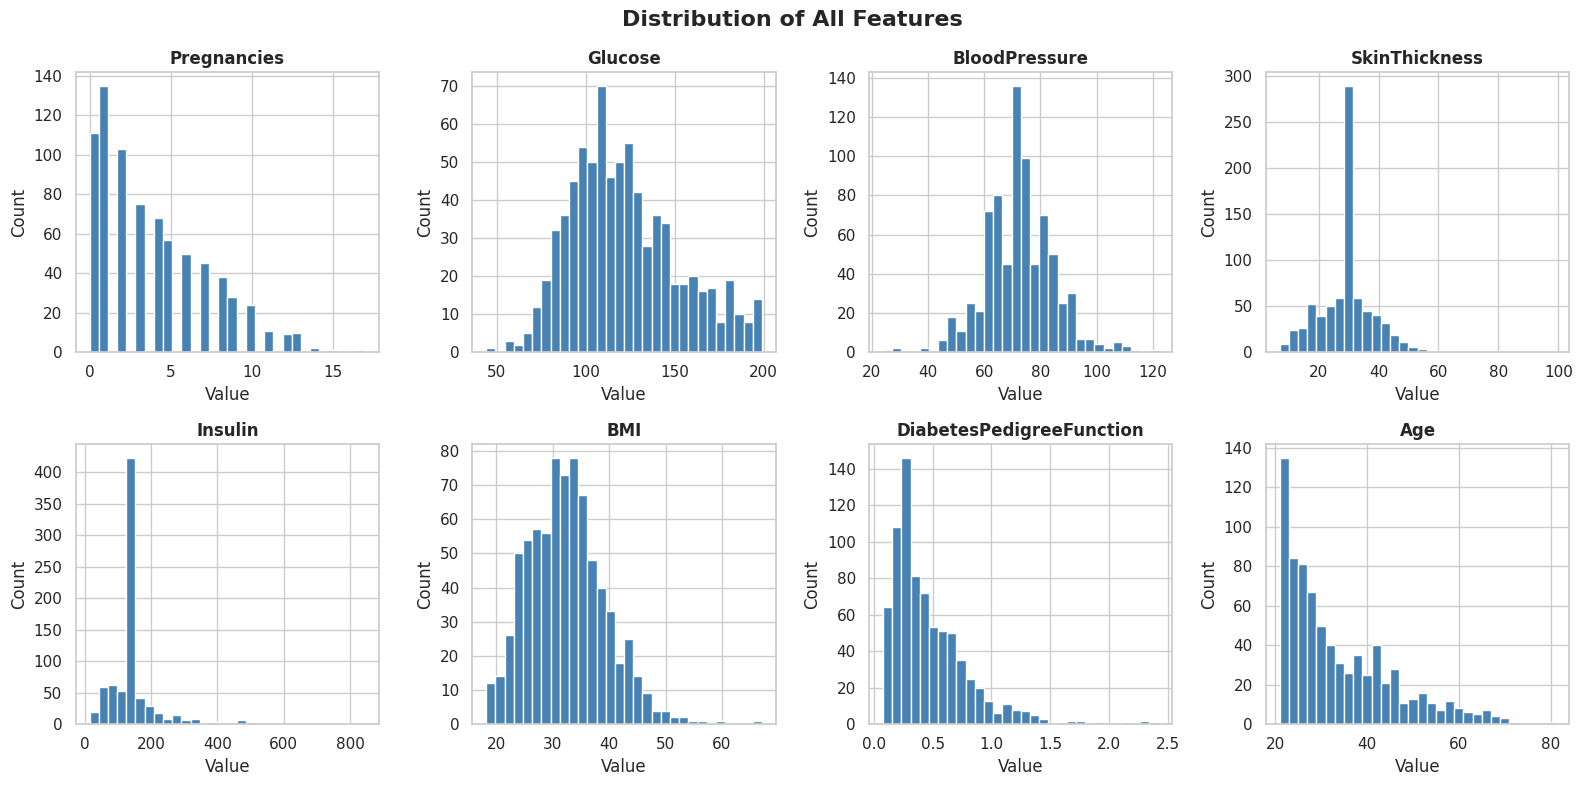

In [34]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df_clean[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Observation — Feature Distributions

- **Glucose** and **BMI** follow a roughly normal distribution, making them reliable features for analysis.
- **Pregnancies**, **Insulin**, and **Age** are right-skewed — most patients are younger with fewer pregnancies.
- **SkinThickness** shows a large spike at the median value, which reflects our earlier imputation of zero values.
- **DiabetesPedigreeFunction** is heavily right-skewed, meaning most patients have a low genetic risk score with a few extreme cases.

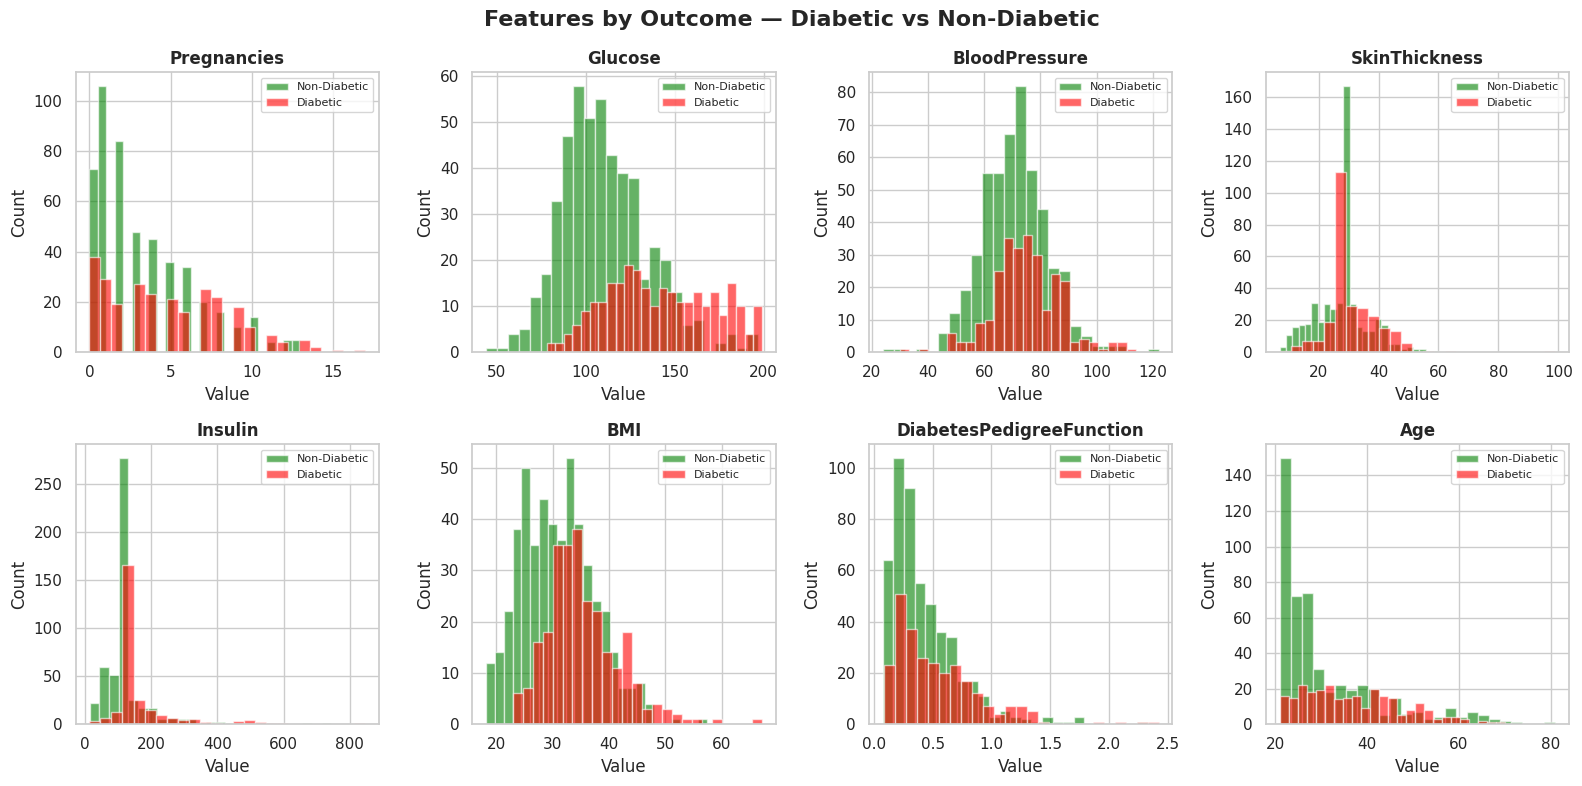

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df_clean[df_clean['Outcome']==0][col], bins=25,
                 alpha=0.6, color='green', label='Non-Diabetic')
    axes[i].hist(df_clean[df_clean['Outcome']==1][col], bins=25,
                 alpha=0.6, color='red', label='Diabetic')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('Features by Outcome — Diabetic vs Non-Diabetic',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Observation — Features by Outcome

- **Glucose** shows the clearest separation — diabetic patients (red)
  are concentrated at higher glucose levels than non-diabetic (green).
- **BMI** and **Age** also show noticeable shifts, with diabetic patients
  skewing higher in both.
- **Pregnancies** shows a slight trend — diabetic patients tend to have
  more pregnancies.
- **Insulin and SkinThickness** show less clear separation, likely due
  to the high number of imputed values.

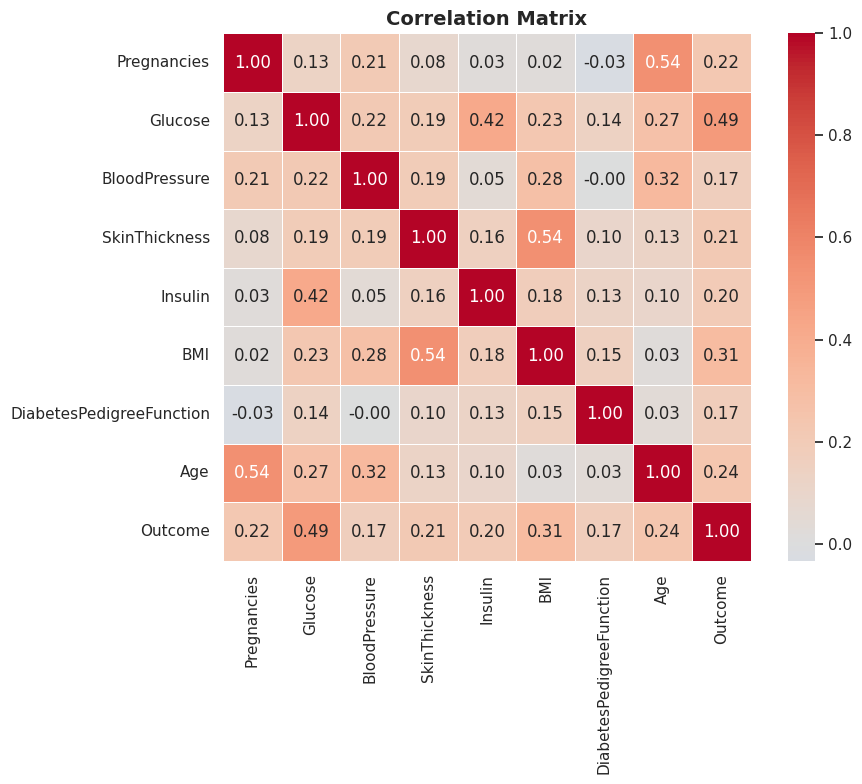

In [36]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(df_clean.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, square=True, ax=ax)

ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observation — Correlation Heatmap

- **Glucose** has the strongest correlation with Outcome (diabetes) —
  the most important predictor in this dataset.
- **BMI** and **Age** also show meaningful positive correlations with Outcome.
- **Pregnancies and Age** are moderately correlated with each other,
  which makes sense — older women have had more pregnancies.
- No features show a strong negative correlation with Outcome.

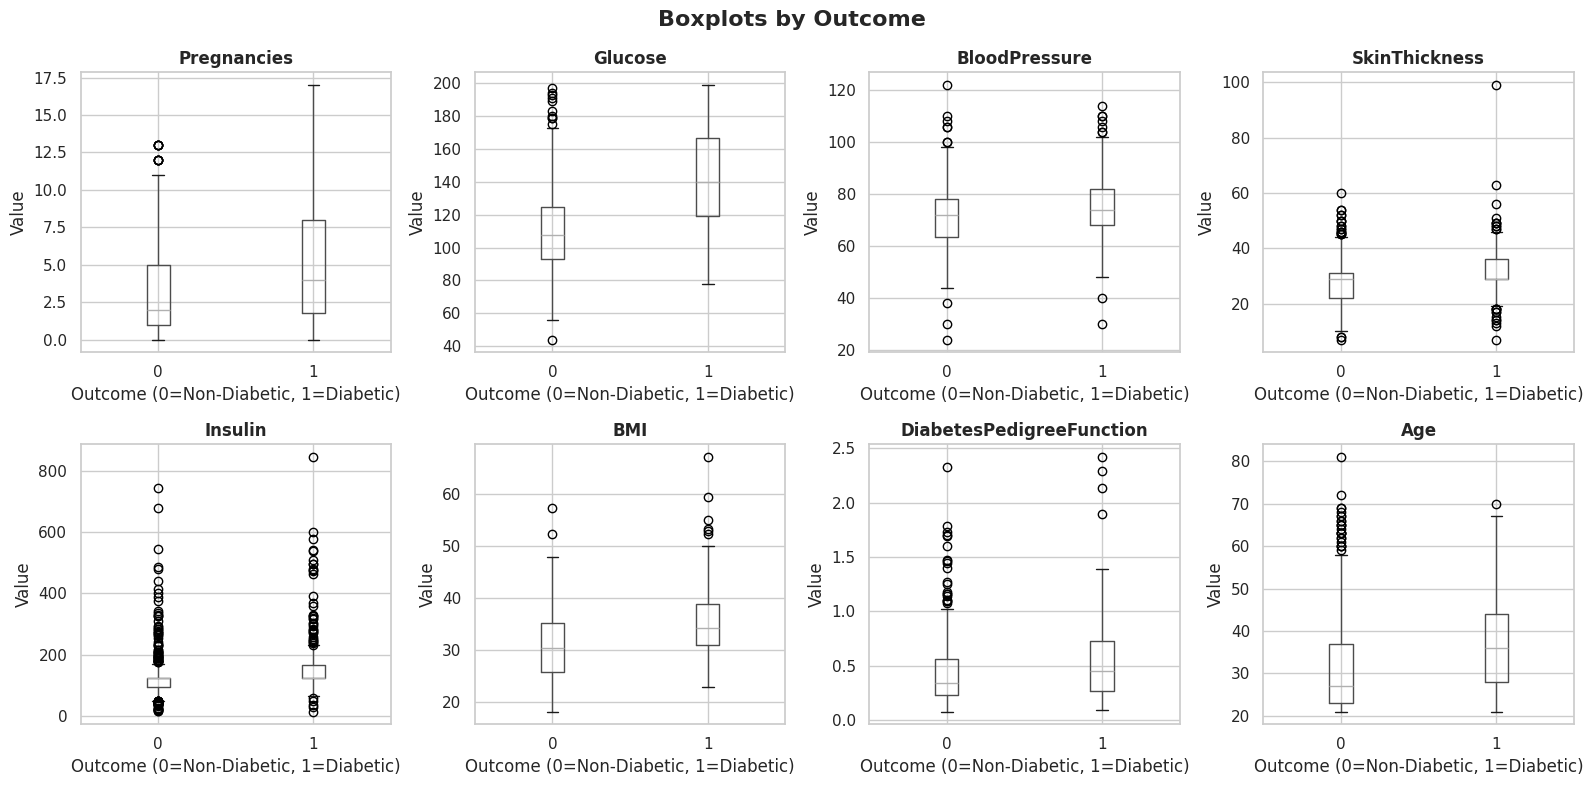

In [37]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    df_clean.boxplot(column=col, by='Outcome', ax=axes[i])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Outcome (0=Non-Diabetic, 1=Diabetic)')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots by Outcome', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Observation — Boxplots by Outcome

- **Glucose** shows the biggest median difference between diabetic (1)
  and non-diabetic (0) patients — confirming it as the top predictor.
- **BMI and Age** also show clear median shifts between the two groups.
- **Insulin** has many outliers (dots above the box), showing high
  variability among diabetic patients.
- **BloodPressure** shows the least difference between groups.

## Key Insight

Glucose level is the single strongest predictor of diabetes in this
dataset. Diabetic patients consistently showed higher glucose levels
across every chart — from distributions to correlations to boxplots.
Combined with BMI and Age, these three features provide the clearest
signal separating diabetic from non-diabetic patients.